# EMPIAR-10379 Data Exploration

This notebook performs the first data-processing step for the
independent reproduction of prismPYP.

Objectives:
1. Load an EMPIAR-10379 cryo-EM micrograph.
2. Inspect its dimensions and numerical properties.
3. Visualize the micrograph in the real domain.
4. Compute its 2D Fourier transform.
5. Compute and visualize its power spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
from pathlib import Path

## 1. Load EMPIAR-10379 Data

In [3]:
from pathlib import Path

data_dir = Path("../data/raw/empiar_10379")

mrc_files = sorted(data_dir.glob("*.mrc"))

print(f"Number of MRC files found: {len(mrc_files)}")

for file in mrc_files:
    print(file.name)

Number of MRC files found: 2
18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00005en-a.mrc


## 2. Inspect a Micrograph

In [4]:
mrc_path = mrc_files[0]

with mrcfile.open(mrc_path, permissive=True) as mrc:
    micrograph = np.array(mrc.data)

print("File:", mrc_path.name)
print("Shape:", micrograph.shape)
print("Data type:", micrograph.dtype)
print("Minimum:", micrograph.min())
print("Maximum:", micrograph.max())
print("Mean:", micrograph.mean())
print("Standard deviation:", micrograph.std())

File: 18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
Shape: (3710, 3838)
Data type: float32
Minimum: 0.06223142
Maximum: 46.456543
Mean: 21.404602
Standard deviation: 3.5968208


## 3. Real-Domain Micrograph

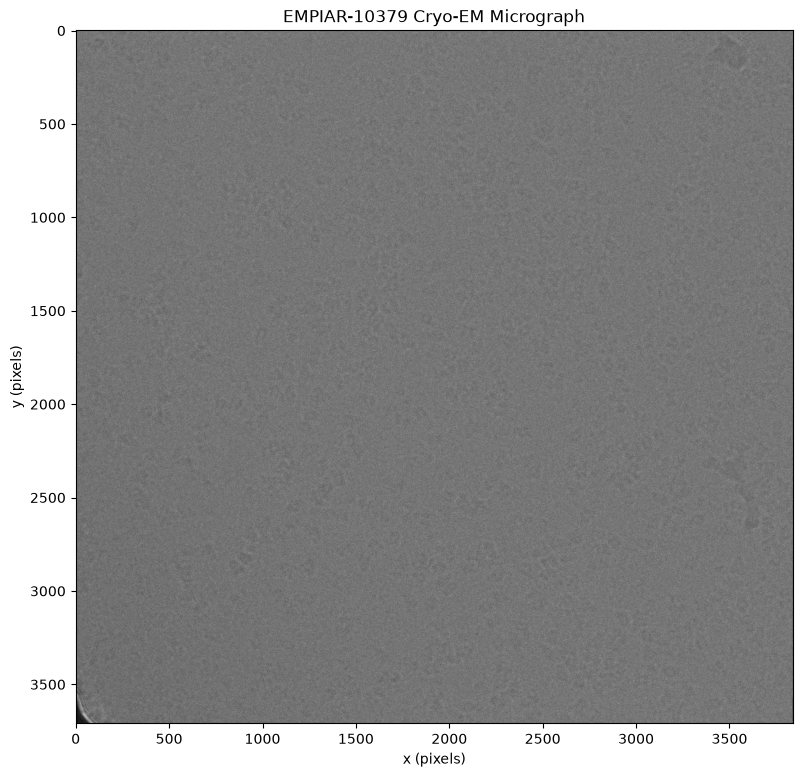

In [7]:
plt.figure(figsize=(12, 9))

plt.imshow(micrograph, cmap="gray")

plt.title("EMPIAR-10379 Cryo-EM Micrograph")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")

plt.show()

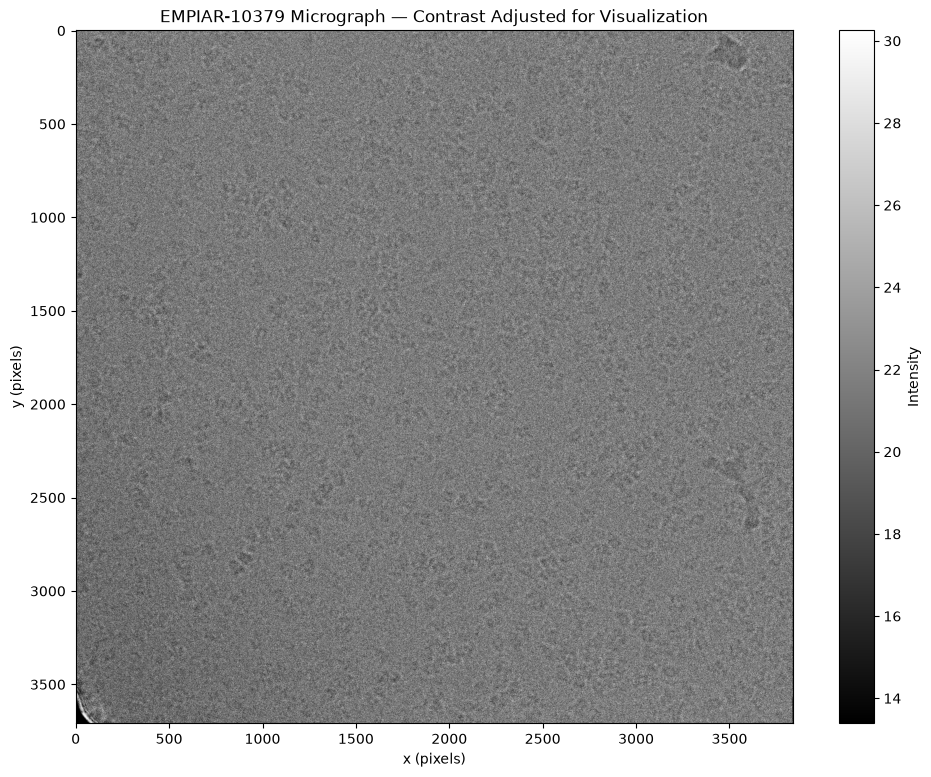

In [9]:
plt.figure(figsize=(12, 9))

plt.imshow(
    micrograph,
    cmap="gray",
    vmin=np.percentile(micrograph, 1),
    vmax=np.percentile(micrograph, 99)
)

plt.title("EMPIAR-10379 Micrograph — Contrast Adjusted for Visualization")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.colorbar(label="Intensity")

plt.show()

## 4. Fourier-Domain Representation

In [11]:
fft = np.fft.fft2(micrograph)

print("Original shape:", micrograph.shape)
print("FFT shape:", fft.shape)
print("FFT data type:", fft.dtype)

Original shape: (3710, 3838)
FFT shape: (3710, 3838)
FFT data type: complex64


In [12]:
# Shift the zero-frequency component to the center
fft_shifted = np.fft.fftshift(fft)

print("Original FFT shape:", fft.shape)
print("Shifted FFT shape:", fft_shifted.shape)

Original FFT shape: (3710, 3838)
Shifted FFT shape: (3710, 3838)


### Fourier Magnitude

In [13]:
# Compute the magnitude of the shifted Fourier transform
magnitude = np.abs(fft_shifted)

print("Magnitude shape:", magnitude.shape)
print("Magnitude minimum:", magnitude.min())
print("Magnitude maximum:", magnitude.max())

Magnitude shape: (3710, 3838)
Magnitude minimum: 3.4840233
Magnitude maximum: 3.047797e+08


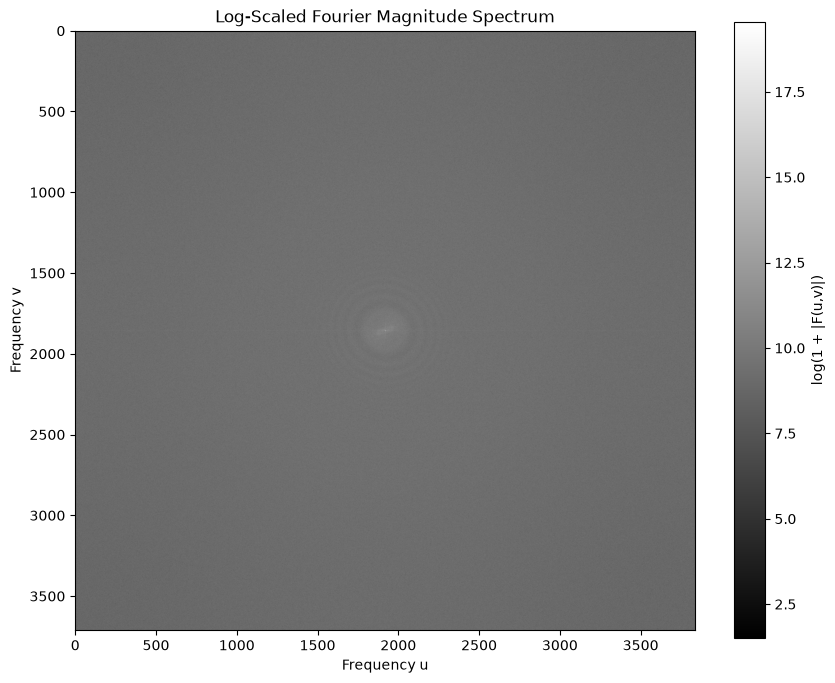

In [14]:
# Log-scaled Fourier magnitude for visualization
log_magnitude = np.log1p(magnitude)

plt.figure(figsize=(10, 8))

plt.imshow(
    log_magnitude,
    cmap="gray"
)

plt.title("Log-Scaled Fourier Magnitude Spectrum")
plt.xlabel("Frequency u")
plt.ylabel("Frequency v")
plt.colorbar(label="log(1 + |F(u,v)|)")

plt.show()

### Power Spectrum

\[
P(u,v) = |F(u,v)|^2
\]

In [18]:
# Power spectrum
power_spectrum = magnitude ** 2
log_power_spectrum = np.log1p(power_spectrum)

print("Power spectrum shape:", power_spectrum.shape)
print("Power spectrum maximum:", power_spectrum.max())

Power spectrum shape: (3710, 3838)
Power spectrum maximum: 9.289068e+16


## 5. Power Spectrum Visualization

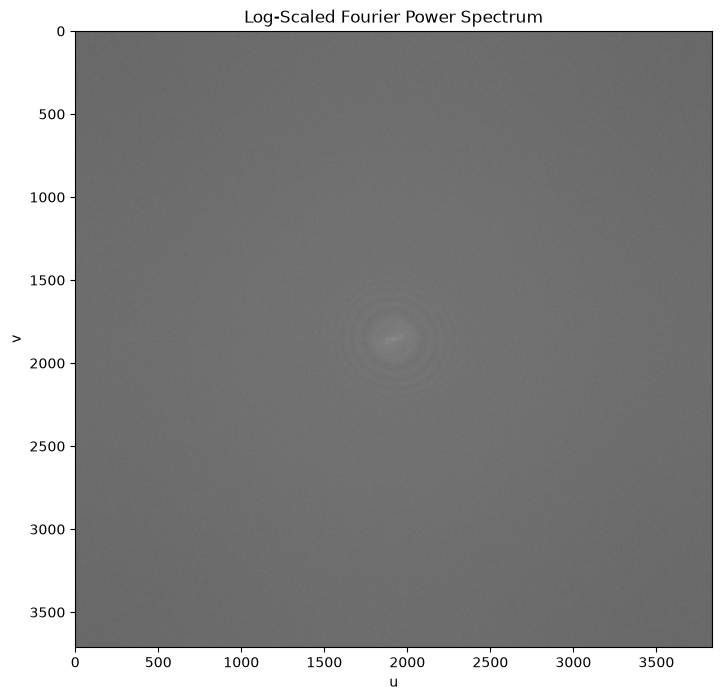

In [22]:
plt.figure(figsize=(10, 8))

plt.imshow(log_power_spectrum, cmap="gray")

plt.title("Log-Scaled Fourier Power Spectrum")
plt.xlabel("u")
plt.ylabel("v")

plt.show()

## 6. Real vs Fourier Domain

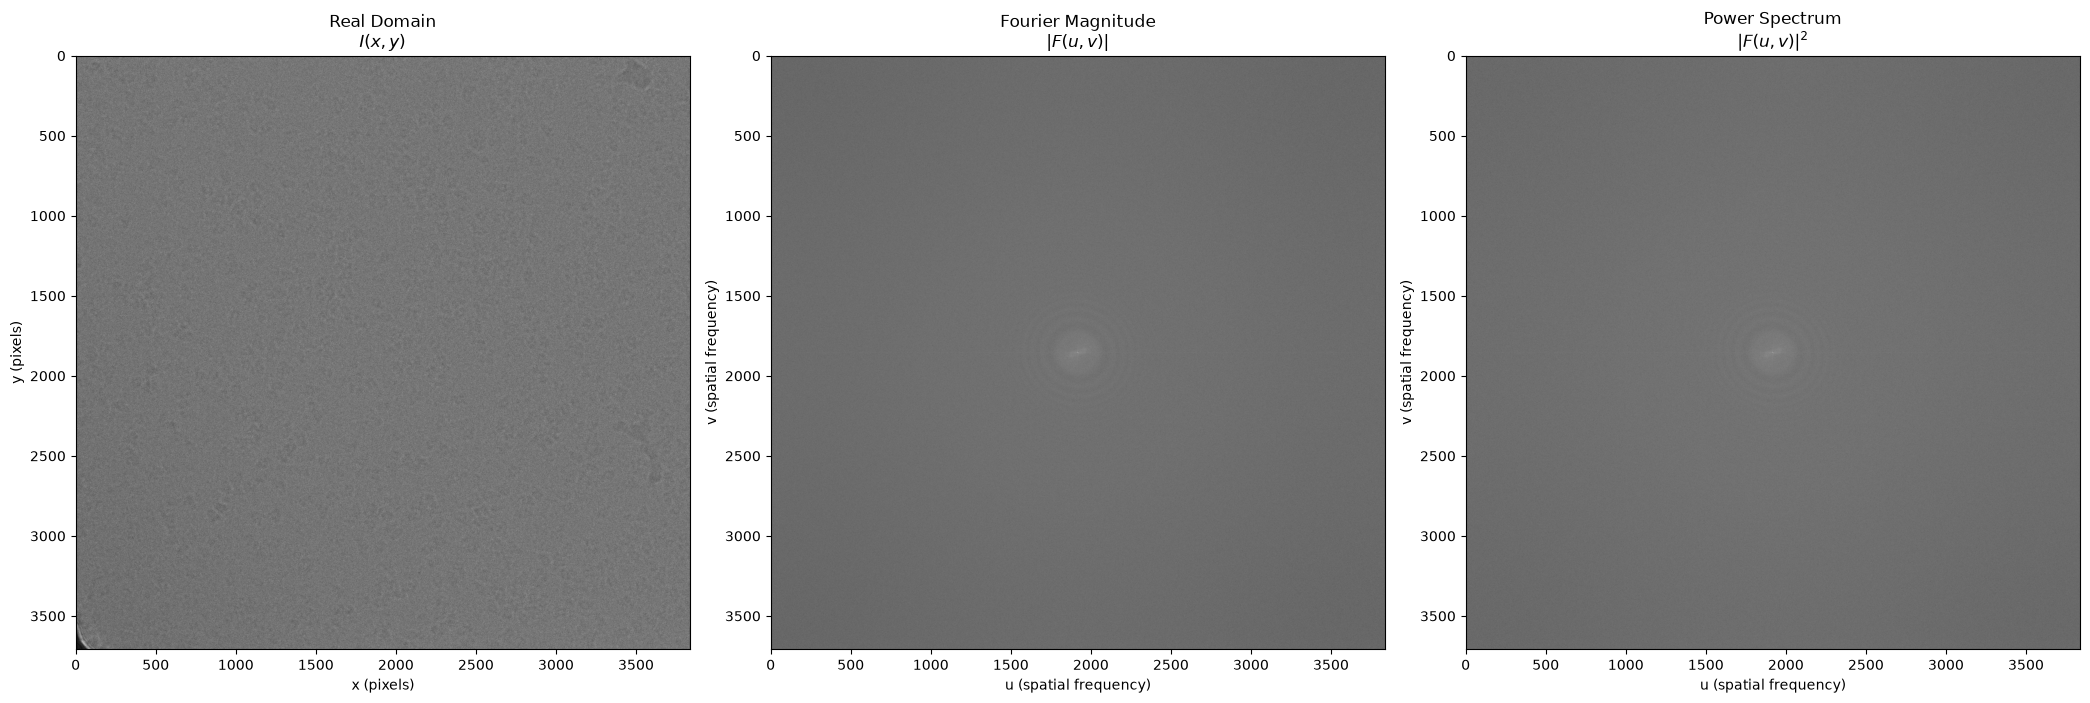

In [19]:
# Compare the micrograph, Fourier magnitude, and power spectrum

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Real domain
axes[0].imshow(micrograph, cmap="gray")
axes[0].set_title("Real Domain\n$I(x,y)$")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")

# Fourier magnitude
axes[1].imshow(log_magnitude, cmap="gray")
axes[1].set_title("Fourier Magnitude\n$|F(u,v)|$")
axes[1].set_xlabel("u (spatial frequency)")
axes[1].set_ylabel("v (spatial frequency)")

# Power spectrum
axes[2].imshow(log_power_spectrum, cmap="gray")
axes[2].set_title("Power Spectrum\n$|F(u,v)|^2$")
axes[2].set_xlabel("u (spatial frequency)")
axes[2].set_ylabel("v (spatial frequency)")

plt.tight_layout()
plt.show()

In [20]:
from pathlib import Path

output_dir = Path("../results/figures")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "real_vs_fourier_power_spectrum.png"

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

print(f"Figure saved to: {output_path}")

Figure saved to: ..\results\figures\real_vs_fourier_power_spectrum.png


### Observation

The Fourier transform provides a frequency-domain representation of the same micrograph. The power spectrum highlights the distribution of signal across spatial frequencies.